# Chapter 26. 한국어 GPT — TinyStories-Korean 으로 작은 언어모델 사전학습 (Ch 24 의 한국어판)

**목표**: Phase 4 의 *한국어 단계 1 (pretraining)* 챕터. Ch 24 에서 *영어 작은 GPT (약 3.7M params) 를 영어 TinyStories 로 from scratch 사전학습* 했다면, 이번엔 **완전히 같은 본체 구조** 로 **한국어 GPT 사전학습** 을 합니다. 변하는 축은 **언어** — 토크나이저는 한국어 코퍼스 위에 직접 학습한 **byte-level BPE (BBPE)**, 데이터는 **`g0ster/TinyStories-Korean`** (영어 TinyStories 의 한국어 번역본). 본체 구조·loss·trainer 는 Ch 24 와 동일 (hyperparams 는 학습률만 `3e-4 → 5e-4`). 같은 prompt 에 *학습 전 / 학습 후* generation 을 나란히 비교해 *사전학습이 본체에 어떤 next-token 분포를 새겼는가* 를 한국어로 직접 봅니다.

**환경**: Google Colab **T4 GPU 필수**.

**예상 소요 시간**: 약 3-5분 (데이터 로드·story 복원 약 20초 + BBPE 토크나이저 학습 약 10초 + 학습 전 generation + 모델 학습 약 1분 + 학습 후 generation + (선택) KoGPT2 reference 로드·생성 약 1분)

---

## 학습 흐름

1. 📊 **누적 추적표 + Phase 4 영어·한국어 대칭** — Ch 24(영어 단계1) ↔ Ch 26(한국어 단계1)
2. 🔄 **변경점** (Diff from Ch 24) — 언어 축: 토크나이저 학습 코퍼스 + 데이터만 한국어
3. 🌏 **Phase 4 학습 4단계 표** — Ch 26 = 단계 1 (한국어 pretraining)
4. 📐 **Loss** — Ch 24 와 동일 (CE next-token). vocab 크기 차이로 random baseline `ln V` 미세 변화만
5. 🔤 **토크나이저 노트** — BBPE 직접 학습 (한국어). Ch 24 영어 BPE 와 비교 + Ch 19 연결
6. 🚀 **실습**: 한국어 TinyStories story 복원 → BBPE 직접 학습 → 작은 `GPT2LMHeadModel` random init
7. 🔬 **사전·사후 generation 비교** — 같은 한국어 prompt 3-4개, *학습 전 (random init) vs 학습 후* 나란히
8. 📦 **등장 라이브러리** / 🎯 **체크포인트** / ❓ **FAQ** (답변 포함)

---

> 📒 **사전 학습 자료**: Ch 24 (영어 GPT scratch + TinyStories), Ch 19 (토크나이저 직접 학습), Ch 22 (영어→한국어 BERT 의 *언어 축* 변화 패턴). 본 챕터는 Ch 24 의 셀 구조를 그대로 가져와 *언어 한 축만* 한국어로 바꿉니다. Ch 20(영어 BERT)→Ch 22(한국어 BERT) 가 그랬듯, Ch 24(영어 GPT)→Ch 26(한국어 GPT) 의 한국어 대칭본.

## 📊 변화 추적표

| Ch | 모델 | 토크나이저 | 데이터 | Output Head | Loss |
|---|---|---|---|---|---|
| 23 | 작은 BERT (한국어, scratch) + 분류 head | `klue/bert-base` (가져옴) | NSMC 이진 | `Linear(H, 2)` | `CrossEntropyLoss` |
| 24 | 작은 GPT2 (약 3.7M, scratch) | BPE (직접 학습, 영어, vocab 2,048) | 영어 TinyStories 30K stories | `Linear(H, V)` (LM head, weight tied) | `CrossEntropyLoss` (next-token) |
| 25 | `gpt2` (124M, OpenAI WebText 사전학습) | BPE (gpt2 그대로, vocab 50,257) | 영어 TinyStories (Ch 24 와 동일) | `Linear(H, V)` (LM head 그대로) | `CrossEntropyLoss` (next-token) - continual pretraining |
| **26 ← 여기** | **작은 GPT2 (약 4.2M, scratch)** | **BBPE (직접 학습, 한국어, vocab 약 4,000)** | **한국어 TinyStories 30K stories** | **`Linear(H, V)` (LM head, weight tied)** | **`CrossEntropyLoss` (next-token)** |
| 27 (다음) | KoGPT2 (`skt/kogpt2-base-v2`, 125M, 대규모 한국어 사전학습) | KoGPT2 BBPE (그대로) | 한국어 TinyStories (Ch 26 과 동일) | `Linear(H, V)` (LM head 그대로) | `CrossEntropyLoss` (next-token) - continual pretraining |

전체 챕터 표는 [루트 README](https://github.com/yoon-gu/neuqes-101#챕터별-변화추적표) 를 참고하세요.

---

## Phase 4 의 영어·한국어 대칭 — Ch 24 ↔ Ch 26

Phase 4 는 영어 (Ch 24-25) 와 한국어 (Ch 26-27) 가 *같은 학습 단계* 를 *언어만 바꿔* 반복하는 구조입니다. Ch 20(영어 BERT)→Ch 22(한국어 BERT) 의 *언어 축 변화* 가 GPT 에서 그대로 반복됩니다.

| 학습 단계 | 영어 | **한국어** |
|---|---|---|
| **단계 1: Pretraining** (random init → scratch 사전학습) | Ch 24 (작은 GPT, 영어 TinyStories) | **Ch 26 ← 여기 (작은 GPT, 한국어 TinyStories)** |
| **단계 2: Continual pretraining** (사전학습 본체 + 새 데이터) | Ch 25 (`gpt2` 124M + 영어 TinyStories) | Ch 27 (KoGPT2 125M + 한국어 TinyStories) |

> **본 챕터 = 한국어 단계 1**. Ch 24 와 *본체·loss·trainer 동일 (hyperparams 는 학습률만 `3e-4 → 5e-4`)*, *토크나이저 학습 코퍼스 + 데이터만 한국어*. 검증 가설: *언어가 달라도 작은 GPT + 30K stories from-scratch 의 학습 동역학은 비슷하다* — Ch 20↔Ch 22 (BERT) 에서 확인한 결을 GPT 에서 재확인.

## 🔄 변경점 (Diff from Ch 24)

| 축 | Ch 24 (영어 GPT scratch) | Ch 26 (한국어 GPT scratch) |
|---|---|---|
| **언어** | 영어 | **한국어** ← *유일한 변화* |
| 토크나이저 학습 코퍼스 | 영어 TinyStories | **한국어 TinyStories** |
| 토크나이저 알고리즘 | byte-level BPE (vocab 2,048) | **byte-level BPE (BBPE, vocab 약 4,000)** - 한글은 byte 단위라 어휘를 약간 키움 |
| 데이터 | `roneneldan/TinyStories` (영어 동화) | **`g0ster/TinyStories-Korean`** (한국어 번역 동화) |
| 본체 구조 | `GPT2Config(n_layer=4, n_head=4, n_embd=256)` 약 3.7M | (그대로) — vocab 2,048 → 4,000 만큼 embedding·LM head 가 커져 **약 4.2M** |
| 모델 클래스 | `GPT2LMHeadModel(config)` random init | (그대로) |
| Collator | `DataCollatorForLanguageModeling(mlm=False)` | (그대로) |
| Loss | `CrossEntropyLoss` (next-token, vocab 2,048 logits) | **`CrossEntropyLoss`** (next-token, vocab 약 4,000 logits) |
| 학습률 | 3e-4 (scratch) | **5e-4** ← 한국어 vocab 에 맞춘 미세 조정 |
| 산출물 | 영어 동화 풍 generation | **한국어 동화 풍 generation** |

> **핵심 변경은 *언어 축*** — Phase 4 안에서 토크나이저 학습 코퍼스와 데이터가 한국어로 바뀝니다. 본체 구조는 Ch 24 와 동일하고, 학습률만 한국어 vocab 에 맞춰 `3e-4 → 5e-4` 로 미세 조정했습니다. *같은 코드를 한국어 토크나이저 + 한국어 데이터로 돌렸을 때 같은 결 (말이 되는 한국어 동화) 이 나오는가* 가 본 챕터의 검증 포인트.

### 왜 한국어는 토크나이저를 *직접* 학습하나 — Ch 25 의 결론 잇기

Ch 25 에서 `gpt2` (영어 WebText) 의 BPE 를 *그대로* 가져와 continual pretraining 했습니다. 영어는 그게 자연스럽습니다 — gpt2 BPE 가 영어 어휘를 잘 커버하니까요. 하지만 *영어 gpt2 BPE 로 한국어를 토큰화하면 한글이 byte 단위로 잘게 쪼개져 토큰 수가 폭증* 합니다 (Ch 25 Q4 / Ch 19 §5-4 의 cross-language 결론). 그래서 한국어는 *한국어 코퍼스 위에 새 토크나이저를 학습* 하는 게 정공법 — 그게 Ch 26 가 다시 *scratch* 인 이유. *토크나이저는 본체와 운명공동체* 원칙이 한국어에서 직접 학습을 강제합니다.

## 🌏 Phase 4 학습 4단계 표 — Ch 26 = 단계 1 (한국어 pretraining)

Ch 24 에서 도입한 *GPT 시대 학습 4단계* 표. 본 챕터는 단계 1 (pretraining) 의 *한국어판* 입니다.

| 단계 | 정확 용어 | 의미 | 학습 신호 (`labels`) | 영어 | 한국어 |
|---|---|---|---|---|---|
| 1 | **Pretraining** (사전학습) | random init 본체부터 일반 코퍼스로 학습 | 거의 모든 토큰 (pad 만 `-100`) | Ch 24 | **Ch 26 ← 여기** |
| 2 | **Continual pretraining** (계속 사전학습) | 사전학습된 본체 + 새 데이터 + 같은 task | 거의 모든 토큰 (단계 1 과 동일) | Ch 25 | Ch 27 |
| 3 | **SFT** (Supervised Fine-Tuning) | instruction-response 쌍으로 행동 정렬 | **답변 토큰만** (`labels[:prompt_len] = -100`) | - | Ch 28 |
| 4 | **Alignment** (DPO / GRPO) | preference / verifier reward 로 선호 정렬 | (RL 내부) | - | Ch 30-31 |

**영어·한국어 대칭** — 단계 1·2 가 영어 (Ch 24·25) ↔ 한국어 (Ch 26·27) 로 짝지어집니다.

| | 단계 1 (Pretraining) | 단계 2 (Continual pretraining) |
|---|---|---|
| 영어 | Ch 24 (작은 GPT scratch) | Ch 25 (`gpt2` 124M) |
| **한국어** | **Ch 26 (작은 GPT scratch) ← 여기** | Ch 27 (KoGPT2 125M) |

> 세 단계 모두 *모델 클래스 그대로* (`AutoModelForCausalLM`), *출력 형식 그대로* (토큰 시퀀스), *학습 신호 종류 그대로* (next-token CE). 다른 점은 *데이터 형식* 과 *`labels = -100` 자리* 뿐. 본 챕터 (단계 1) 는 *pad 만 `-100`* — 거의 모든 자리가 학습 신호. Ch 28 (SFT) 의 *prompt 만 `-100`* 이 정반대 자리 (클라이맥스).

## 💡 `labels = -100` thread — 한국어에서 한 줄 재확인

Ch 20·22 의 BERT MLM 에서 봤던 `labels = -100` ignore_index 트릭은 GPT CausalLM 사전학습에서도 등장하지만 *적용 자리가 정반대* 였습니다 (Ch 24 에서 영어로 확인). 한국어에서도 *완전히 동일* — collator 코드는 토큰 id 위에서만 동작하므로 언어와 무관합니다.

| 단계 | 챕터 | `labels` 구성 | loss 계산 자리 |
|---|---|---|---|
| MLM 사전학습 | Ch 20 (영어), Ch 22 (한국어) | 선택된 약 15% 만 원본 token id, 나머지 `-100` | *가려진 자리만* |
| GPT CausalLM 사전학습 (영어) | Ch 24 | `input_ids.clone()` - pad 만 `-100` | 거의 *전 자리* |
| **GPT CausalLM 사전학습 (한국어)** | **Ch 26 (본 챕터)** | **`input_ids.clone()` - pad 만 `-100`** | **거의 *전 자리*** |
| SFT / Instruction Tuning | Ch 28 (한국어 SFT) | **prompt 부분 `-100`**, 답변 토큰만 원본 id | *답변 부분만* |

> 같은 `-100` 트릭, *적용 자리만 정반대*. 한국어 CausalLM 사전학습도 *거의 모든 자리* 가 학습 신호 (MLM 대비 약 5-6배 효율). 본 챕터에서는 `DataCollatorForLanguageModeling(mlm=False)` 이 자동으로 `labels = input_ids.clone()` 을 만듭니다 — 뒤 collator 출력 셀에서 한국어 토큰으로 직접 확인합니다. Ch 28 (한국어 SFT) 의 *왜 모델이 instruction 을 따라가게 되는가* 는 *한 줄 `labels[:prompt_len] = -100`* 으로 설명되는데, 그 토대가 *이 챕터의 collator 출력* 입니다.

## 📐 Loss — `CrossEntropyLoss` (next-token), Ch 24 와 동일

이번 챕터는 *언어만 바뀌고* loss 함수는 Ch 24 와 동일한 next-token CrossEntropyLoss. 다만 vocab 크기가 달라 random baseline `ln V` 가 미세하게 이동합니다.

### 수식 (Ch 24 와 동일)

입력 토큰 시퀀스 $x = (x_1, \dots, x_n)$ 에 대해, 각 위치 $i$ 에서 *그 다음 토큰* $x_{i+1}$ 을 예측:

$$L_{\text{CLM}} = -\frac{1}{n-1} \sum_{i=1}^{n-1} \log P(x_{i+1} \mid x_1, \dots, x_i)$$

- $P(x_{i+1} \mid x_{\leq i})$: 모델이 *지금까지 본 토큰만으로* 다음 토큰을 예측할 확률 (vocab 약 4,000 차원 softmax)
- 평균 분모 $n-1$: pad 가 아닌 *거의 모든* 자리에서 loss 계산

### vocab 차이가 random baseline 에 주는 미세한 영향

| 토크나이저 | vocab size $V$ | random baseline $\ln V$ | random PPL $= V$ |
|---|---|---|---|
| BPE (Ch 24, 영어) | 2,048 | **7.62** | 2,048 |
| BBPE (Ch 26, 한국어) | 약 4,000 | **약 8.29** | 약 4,000 |

한글은 byte 단위로 표현되어 *같은 의미를 담으려면 vocab 을 약간 키우는* 게 자연스럽습니다 (그렇지 않으면 한 글자가 여러 byte 조각으로 잘게 쪼개짐). vocab 을 약 4,000 으로 잡으면 random baseline 이 약 8.29.

### 숫자로 감 잡기 (vocab 약 4,000)

| 모델 상태 | 정답 토큰 확률 | $-\log p$ |
|---|---|---|
| 균등 추측 (random init 직후) | $1/4000 = 2.5 \times 10^{-4}$ | **약 8.29** ← random baseline |
| 약하게 학습 (정답 확률 0.01-0.02) | $0.01$ - $0.02$ | **3.9 - 4.6** ← 1500 step (1분) 도달 영역 (번역체) |
| 잘 학습된 작은 GPT (정답 확률 0.05-0.15) | $0.05$ - $0.15$ | $1.9$ - $3.0$ (더 길게 학습 시) |
| 큰 사전학습 GPT (정답 확률 0.3+) | $0.3$ | 1.20 |

**관전 포인트**:
- 학습 첫 step loss 가 약 8.3 부근이면 random init 직후 *균등 추측* 상태. 첫 100 step 안에 빠르게 떨어지면 vocab + 모델 정상.
- 1분 (1500 step) 학습으로 누적 평균 `train_loss` 가 *약 4.5* 까지 내려갑니다. 번역체 한국어라 영어 챕터 (Ch 24, 약 3.7) 보다 다소 높지만 (학습률도 `3e-4 → 5e-4` 로 달라 언어 차이만의 효과는 아님), *vocab 후보를 좁히는* 단계로 진입한 수준 — Ch 24 (영어) 와 같은 결. 더 길게 학습하면 약 2.5-3.0 까지 내려갑니다.

> Ch 24 의 `ln(2048) ≈ 7.62` 와 같은 직관. *vocab 차원* 만 약간 커진 것 (약 4,000) — 학습 동역학에는 영향 없고, *학습 종료 loss 의 절대값* 을 영어 챕터와 비교할 때만 미세 보정.

## 🔤 토크나이저 노트 — BBPE 직접 학습 (한국어, vocab 약 4,000)

Ch 24 와 같은 종류 (byte-level BPE) 의 토크나이저를 *한국어 코퍼스 위에* 직접 학습합니다. Ch 19 의 토크나이저 직접 학습 + Ch 24 의 영어 BPE 의 *한국어판*.

| 토크나이저 | 학습 코퍼스 | 등장 챕터 |
|---|---|---|
| WordLevel / WordPiece | (직접 학습) | Ch 19 |
| BPE (byte-level, 영어) | 영어 TinyStories | Ch 24 (직접 학습) |
| **BPE (byte-level, 한국어 = BBPE)** | **한국어 TinyStories** | **Ch 26 (본 챕터, 직접 학습)** |

### byte-level BPE 가 한글을 다루는 법 — UNK 없음

byte-level BPE 의 핵심: *가장 작은 단위가 byte (256개)* 라 *어떤 유니코드 문자열* (한글, 이모지, 한자) 도 *UNK 없이* 표현 가능합니다. 한글 한 글자 `가` 는 UTF-8 로 3 byte (`EA B0 80`) — BBPE 는 이 byte 들을 학습 중 *자주 함께 등장하는 쌍* 으로 병합해 *글자·어절 단위* 토큰을 만들어 갑니다.

- **영어 BPE (Ch 24)**: `"Once upon a time"` → 자주 등장하는 표현이라 적은 토큰으로 압축
- **한국어 BBPE (Ch 26)**: `"옛날 옛날에"` → 한국어 코퍼스에 자주 등장하는 어절은 적은 토큰으로 압축, 드문 어절은 byte 조각으로 분할

### 같은 한국어 문장: 영어 BPE (gpt2) vs 한국어 BBPE (본 챕터)

`gpt2` 의 영어 BPE 로 `"옛날 옛날에 작은 토끼가 살았어요"` 를 토큰화하면 한글 한 글자가 *여러 byte 조각* 으로 잘게 쪼개져 토큰 수가 폭증합니다 (UNK 는 없지만 의미 단위가 사라짐). 한국어 BBPE 로 학습하면 *같은 문장이 훨씬 적은, 의미 있는 토큰* 으로 표현됩니다 — 뒤 토크나이저 학습 셀에서 직접 비교합니다.

### 특수 토큰 컨벤션 (Ch 24 와 동일)

GPT 계열은 특수 토큰을 *최소화* — `<|endoftext|>` 하나로 bos = eos = pad 겸용. 마침 한국어 TinyStories 데이터도 story 경계를 `<|endoftext|>` 로 표시하고 있어 컨벤션이 자연스럽게 일치합니다.

> Ch 19 의 "토크나이저는 모델과 운명공동체" 원칙이 본 챕터에서도 유효 — vocab 약 4,000 의 BBPE 를 직접 학습한 뒤, *같은 vocab 으로 GPT 본체를 random init* 합니다. Ch 27 에서는 *반대로* KoGPT2 의 사전학습된 BBPE + 본체를 그대로 가져와 continual pretraining — 토크나이저 + 모델이 *함께* 변하는 게 Ch 26-27 의 핵심 비교 (Ch 24-25 의 한국어 짝).

## 🛠️ 환경 셋업

In [1]:
%pip install -q -U transformers tokenizers datasets accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━ 34.5/50.1 MB 260.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 50.1/50.1 MB 263.0 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 20.8 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# device 자동 감지 - Colab T4 / 로컬 MPS / CPU 모두 지원
if torch.cuda.is_available():
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"device     : cuda  ({device_name})")
    print(f"VRAM total : {vram_gib:.2f} GiB")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("device     : mps  (Apple Silicon)")
else:
    device = torch.device("cpu")
    print("device     : cpu  (training will be very slow - Colab T4 recommended)")

print(f"torch      : {torch.__version__}")

# 재현성
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# fp16 은 CUDA 에서만 (MPS 는 미지원, CPU 는 의미 없음)
USE_FP16 = (device.type == "cuda")
print(f"use fp16   : {USE_FP16}")

# matplotlib 한글 폰트 (Colab — NanumGothic). plot 의 한국어가 □ 로 깨지지 않게.
import matplotlib.pyplot as plt, matplotlib.font_manager as fm, subprocess, os
_fp = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not os.path.exists(_fp):
    subprocess.run("apt-get -qq -y install fonts-nanum", shell=True)
fm.fontManager.addfont(_fp)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


device     : cuda  (Tesla T4)
VRAM total : 14.56 GiB
torch      : 2.11.0+cu128
use fp16   : True


## 1. 한국어 TinyStories 데이터 로드 + story 복원

`g0ster/TinyStories-Korean` 은 영어 `roneneldan/TinyStories` 를 한국어로 번역한 동화 데이터셋 (Dohoon Kim, 2024, MIT 라이선스). 어휘·문법이 단순해 **약 4.2M 파라미터** 짜리 작은 모델로도 한국어 문장 생성을 시연할 수 있습니다.

**데이터 구조 주의** — 이 데이터셋은 *story 단위가 아니라 줄(line) 단위* 로 저장되어 있습니다. 한 story 가 여러 줄로 나뉘어 있고, story 끝마다 `<|endoftext|>` 줄이 들어가며, 사이에 빈 줄도 섞여 있습니다. 그래서 *`<|endoftext|>` 를 만날 때까지 줄을 이어 붙여* 한 story 로 복원합니다. 그렇게 복원한 처음 **30,000 stories** 만 사용 (Ch 24 와 같은 규모, T4 30분 룰 안).

In [3]:
from datasets import load_dataset

EOT_MARK = "<|endoftext|>"      # 데이터셋이 story 경계 표시에 쓰는 마커
N_TRAIN  = 30_000               # 복원할 story 수 (더 길게 돌리려면 키우세요)
N_VAL    = 500
# story 30K 를 복원하려면 줄을 넉넉히 스트리밍해야 합니다 (story 당 평균 여러 줄 + 빈 줄).
MAX_LINES_TO_SCAN = 800_000

# train/validation 모두 한 줄(text) 짜리 스키마. 스트리밍으로 필요한 만큼만 읽음.
def rebuild_stories(split, n_stories, max_lines):
    '''줄 단위 데이터를 <|endoftext|> 기준으로 이어 붙여 story 리스트로 복원.'''
    stories, buf = [], []
    stream = load_dataset("g0ster/TinyStories-Korean", split=split, streaming=True)
    for i, ex in enumerate(stream):
        if i >= max_lines or len(stories) >= n_stories:
            break
        line = (ex["text"] or "").strip()
        if line == EOT_MARK:
            story = " ".join(buf).strip()
            if story:
                stories.append(story)
            buf = []
        elif line:
            buf.append(line)
    # 버퍼에 남은 마지막 story 도 수습
    if buf and len(stories) < n_stories:
        tail = " ".join(buf).strip()
        if tail:
            stories.append(tail)
    return stories[:n_stories]

t0 = time.time()
train_stories = rebuild_stories("train", N_TRAIN, MAX_LINES_TO_SCAN)
val_stories   = rebuild_stories("validation", N_VAL, 50_000)
print(f"rebuilt stories: train={len(train_stories):,}, val={len(val_stories):,}  ({time.time()-t0:.1f}s)")

from datasets import Dataset
raw_train = Dataset.from_dict({"text": train_stories})
raw_val   = Dataset.from_dict({"text": val_stories})
print("train:", raw_train)
print("val  :", raw_val)

# 길이 통계 + 샘플
lens = [len(s) for s in train_stories]
print(f"\nstory length (chars): mean={np.mean(lens):.0f}, median={np.median(lens):.0f}, max={max(lens)}")
print("\n=== sample story ===")
print(raw_train[0]["text"][:400])

README.md:   0%|          | 0.00/789 [00:00<?, ?B/s]

rebuilt stories: train=30,000, val=500  (19.7s)
train: Dataset({
    features: ['text'],
    num_rows: 30000
})
val  : Dataset({
    features: ['text'],
    num_rows: 500
})

story length (chars): mean=468, median=420, max=2754

=== sample story ===
한때 벤이라는 이름의 어린 소년이 있었어요. 벤은 주변 세계를 탐험하는 것을 좋아했답니다. 그는 가게에 전시되어 있던 아름다운 꽃병들 같은 멋진 것들을 많이 봤어요. 어느 날, 벤은 가게를 거닐다가 정말 특별한 꽃병을 발견했죠. 벤은 그 꽃병을 보고 놀라워하며 말했습니다. "와, 정말 멋진 꽃병이야! 살 수 있을까?" 상점 주인도 웃으며 대답했어요. "물론이지. 집에 가져가서 친구들한테 얼마나 멋진지 보여줄 수 있어!" 그래서 벤은 그 꽃병을 집에 가져갔고, 정말 자랑스러웠답니다. 벤은 친구들을 불러서 놀라운 꽃병을 보여주었어요. 벤의 모든 친구들은 꽃병을 보고 아름답다고 생각하며 벤이 얼마나 운이 좋은지 믿을 수가 없었죠. 그렇게 벤은 가게에서 멋진 꽃병을 발견했답니다!


## 2. BBPE 토크나이저 직접 학습 (한국어)

`tokenizers.BPE` + ByteLevel pre-tokenizer 로 vocab 약 4,000 의 byte-level BPE 를 *한국어 코퍼스에서 직접* 학습합니다. Ch 24 의 영어 BPE 와 *같은 절차* — 다른 점은 *학습 코퍼스* (영어 → 한국어) 와 *vocab 크기* (2,048 → 약 4,000, 한글 byte 표현을 위해 약간 키움) 뿐.

In [4]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel
from tokenizers.decoders import ByteLevel as ByteLevelDecoder
from transformers import PreTrainedTokenizerFast

VOCAB_SIZE = 4000     # 한국어는 byte 단위라 영어(2048)보다 약간 키움
EOS = "<|endoftext|>"

bbpe = Tokenizer(BPE(unk_token=None))
bbpe.pre_tokenizer = ByteLevel(add_prefix_space=False)
bbpe.decoder = ByteLevelDecoder()
trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=[EOS],
    initial_alphabet=ByteLevel.alphabet(),
    show_progress=True,
)

t0 = time.time()
bbpe.train_from_iterator((ex["text"] for ex in raw_train), trainer, length=len(raw_train))
print(f"BBPE training done: {time.time()-t0:.1f}s, vocab={bbpe.get_vocab_size()}")

# HF 표준 인터페이스로 wrap - bos = eos = pad 모두 <|endoftext|> 로 (GPT 컨벤션)
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=bbpe,
    bos_token=EOS,
    eos_token=EOS,
    pad_token=EOS,
)

print("\n=== encode/decode demo (Korean) ===")
sample = "옛날 옛날에 작은 토끼가 숲으로 갔어요."
enc = tokenizer(sample)
print(f"input      : {sample}")
print(f"ids        : {enc['input_ids']}")
print(f"n_tokens   : {len(enc['input_ids'])}")
print(f"decode     : {tokenizer.decode(enc['input_ids'])}")
print(f"vocab_size : {tokenizer.vocab_size}")
print(f"eos_token  : {tokenizer.eos_token}  id={tokenizer.eos_token_id}")

BBPE training done: 8.8s, vocab=4000

=== encode/decode demo (Korean) ===
input      : 옛날 옛날에 작은 토끼가 숲으로 갔어요.
ids        : [645, 2132, 455, 2358, 1115, 452, 894, 14]
n_tokens   : 8
decode     : 옛날 옛날에 작은 토끼가 숲으로 갔어요.
vocab_size : 4000
eos_token  : <|endoftext|>  id=0


### 🌐 같은 한국어 문장: 영어 BPE (gpt2) vs 한국어 BBPE (본 챕터)

`gpt2` 의 영어 BPE 로 한국어를 토큰화하면 한글이 *byte 단위로 잘게 쪼개져* 토큰 수가 폭증합니다. 우리가 한국어 코퍼스 위에 직접 학습한 BBPE 와 *같은 문장* 을 비교해 봅니다 (Ch 25 Q4 / Ch 19 §5-4 의 cross-language 결론을 한국어 generation 챕터에서 실측).

In [5]:
from transformers import AutoTokenizer

# 영어 gpt2 BPE 로드 (비교용)
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")

ko_sentences = [
    "옛날 옛날에 작은 토끼가 살았어요.",
    "큰 개가 공원에서 신나게 뛰어놀았어요.",
    "작은 소녀가 엄마에게 꽃을 주었어요.",
]

rows = []
for sent in ko_sentences:
    n_gpt2 = len(gpt2_tok(sent, add_special_tokens=False)["input_ids"])
    n_ours = len(tokenizer(sent, add_special_tokens=False)["input_ids"])
    rows.append({
        "sentence": sent,
        "gpt2_BPE_tokens": n_gpt2,
        "ours_BBPE_tokens": n_ours,
        "ratio_gpt2/ours": round(n_gpt2 / n_ours, 2),
    })

cmp_df = pd.DataFrame(rows)
print("Korean tokenization: English gpt2 BPE vs our Korean BBPE")
print("=" * 70)
print(cmp_df.to_string(index=False))
print("\n=> gpt2 BPE splits Korean into many byte fragments (more tokens).")
print("   Our Korean BBPE keeps meaningful units (fewer tokens).")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Korean tokenization: English gpt2 BPE vs our Korean BBPE
             sentence  gpt2_BPE_tokens  ours_BBPE_tokens  ratio_gpt2/ours
  옛날 옛날에 작은 토끼가 살았어요.               43                 6             7.17
큰 개가 공원에서 신나게 뛰어놀았어요.               51                 8             6.38
 작은 소녀가 엄마에게 꽃을 주었어요.               45                 7             6.43

=> gpt2 BPE splits Korean into many byte fragments (more tokens).
   Our Korean BBPE keeps meaningful units (fewer tokens).


**관전 포인트** — `옛날 옛날에` 처럼 한국어 코퍼스에 *자주 등장* 하는 표현은 우리 BBPE 가 *적은 토큰* 으로 압축합니다. 영어 gpt2 BPE 는 같은 문장을 *2-4배 많은 byte 조각* 으로 쪼갭니다 — UNK 는 없지만 *의미 단위* 가 사라져, 그 위에서 학습하면 한국어 정보를 압축할 자리가 부족합니다. *왜 한국어는 토크나이저를 직접 학습하는가* 의 실측 답.

## 3. 토큰화 + `group_texts` (HF 표준 CLM 전처리)

Ch 24 와 *완전히 같은 패턴* (HF `run_clm.py` 표준):

1. 전체 코퍼스를 토큰화 (배치 단위)
2. 각 story 끝에 `<|endoftext|>` 부착 (story 경계 표시)
3. 모든 토큰을 이어붙여 1D 스트림으로 만든 뒤 `block_size=128` 단위로 잘라 chunk 화
4. 각 chunk 가 한 학습 sample - `DataCollatorForLanguageModeling(mlm=False)` 가 `labels = input_ids` 를 자동으로 채워 next-token prediction loss 가 됨

In [6]:
BLOCK_SIZE = 128

def tokenize_fn(batch):
    return tokenizer(batch["text"])

# 토큰화 (text 컬럼 제거)
tok_train = raw_train.map(tokenize_fn, batched=True, remove_columns=["text"], desc="tokenize train")
tok_val   = raw_val.map(tokenize_fn,   batched=True, remove_columns=["text"], desc="tokenize val")

# 각 story 끝에 EOS 부착 (story 경계 표시)
def add_eos(batch):
    new_ids, new_mask = [], []
    for ids in batch["input_ids"]:
        ids = ids + [tokenizer.eos_token_id]
        new_ids.append(ids)
        new_mask.append([1] * len(ids))
    return {"input_ids": new_ids, "attention_mask": new_mask}

tok_train = tok_train.map(add_eos, batched=True, desc="add eos train")
tok_val   = tok_val.map(add_eos,   batched=True, desc="add eos val")

# group_texts - 모든 토큰을 이어붙여 BLOCK_SIZE 단위로 자름
def group_texts(batch):
    concatenated = {k: sum(batch[k], []) for k in batch.keys()}
    total_len = len(concatenated["input_ids"])
    total_len = (total_len // BLOCK_SIZE) * BLOCK_SIZE
    return {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_len, BLOCK_SIZE)]
        for k, t in concatenated.items()
    }

lm_train = tok_train.map(group_texts, batched=True, desc="group train")
lm_val   = tok_val.map(group_texts,   batched=True, desc="group val")

print(f"\ntrain chunks: {len(lm_train):,}  (block_size={BLOCK_SIZE})")
print(f"val   chunks: {len(lm_val):,}")
print(f"approx. train tokens: {len(lm_train) * BLOCK_SIZE / 1e6:.2f} M")
print("\nfirst chunk decode (first 200 chars):")
print(tokenizer.decode(lm_train[0]["input_ids"])[:200])

tokenize train:   0%|          | 0/30000 [00:00<?, ? examples/s]

tokenize val:   0%|          | 0/500 [00:00<?, ? examples/s]

add eos train:   0%|          | 0/30000 [00:00<?, ? examples/s]

add eos val:   0%|          | 0/500 [00:00<?, ? examples/s]

group train:   0%|          | 0/30000 [00:00<?, ? examples/s]

group val:   0%|          | 0/500 [00:00<?, ? examples/s]


train chunks: 45,845  (block_size=128)
val   chunks: 750
approx. train tokens: 5.87 M

first chunk decode (first 200 chars):
한때 벤이라는 이름의 어린 소년이 있었어요. 벤은 주변 세계를 탐험하는 것을 좋아했답니다. 그는 가게에 전시되어 있던 아름다운 꽃병들 같은 멋진 것들을 많이 봤어요. 어느 날, 벤은 가게를 거닐다가 정말 특별한 꽃병을 발견했죠. 벤은 그 꽃병을 보고 놀라워하며 말했습니다. "와, 정말 멋진 꽃병이야! 살 수 있을까?" 상점 주인도 웃으며 대답했어요. "물론


### 🔬 Collator 가 만드는 `labels` 확인 (한국어) - *거의 모든 자리* 가 학습 신호

`DataCollatorForLanguageModeling(mlm=False)` 가 *내부적으로* `labels = input_ids.clone()` 을 만들어 `-100` 자리는 *없거나 pad 토큰 자리만* 임을 한국어 데이터로 직접 확인합니다. Ch 20·22 의 MLM collator 가 약 85% 를 `-100` 으로 채웠던 것과 *정확히 반대* — Ch 24 (영어) 에서 본 결과의 한국어 재확인.

In [7]:
from transformers import DataCollatorForLanguageModeling

collator_demo = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
demo_batch = collator_demo([lm_train[0], lm_train[1]])

input_ids = demo_batch["input_ids"]
labels = demo_batch["labels"]

print(f"input_ids shape: {tuple(input_ids.shape)}")
print(f"labels shape   : {tuple(labels.shape)}")

# -100 자리 vs 학습 신호 자리 비율
total = labels.numel()
n_ignored = (labels == -100).sum().item()
n_train_signal = total - n_ignored
print(f"\n=== 'labels = -100' thread - CausalLM vs MLM comparison (Korean) ===")
print(f"total positions      : {total}")
print(f"  ignored (-100)     : {n_ignored:>5d}  ({100 * n_ignored / total:5.2f}%)")
print(f"  train signal       : {n_train_signal:>5d}  ({100 * n_train_signal / total:5.2f}%)")
print(f"\n[MLM (Ch 20/22)]     approx. 85% = -100, 15% = train signal")
print(f"[CausalLM (this ch)] {100 * n_ignored / total:5.2f}% = -100, {100 * n_train_signal / total:5.2f}% = train signal  <- almost every position")
print(f"\n=> a single step's token-learning efficiency: GPT pretrain is approx. 5-6x higher than MLM")

# input_ids 와 labels 의 동일성 검증 (pad 가 아닌 자리)
identical = (input_ids == labels).sum().item()
print(f"\n(input_ids == labels) positions: {identical}/{total}  - clone as-is")

input_ids shape: (2, 128)
labels shape   : (2, 128)

=== 'labels = -100' thread - CausalLM vs MLM comparison (Korean) ===
total positions      : 256
  ignored (-100)     :     1  ( 0.39%)
  train signal       :   255  (99.61%)

[MLM (Ch 20/22)]     approx. 85% = -100, 15% = train signal
[CausalLM (this ch)]  0.39% = -100, 99.61% = train signal  <- almost every position

=> a single step's token-learning efficiency: GPT pretrain is approx. 5-6x higher than MLM

(input_ids == labels) positions: 255/256  - clone as-is


> **`-100` thread 환기 (한국어)** - 언어가 한국어로 바뀌어도 collator 동작은 동일. CausalLM 은 *거의 모든 자리* 학습. Ch 28 (한국어 SFT) 에서는 *prompt 자리만 -100* - 같은 트릭의 정반대 자리. 그 한 줄 코드가 *모델이 한국어 instruction 을 따라가게 만드는 핵심* 이고, 본 챕터의 collator 셋업이 그 토대입니다.

## 4. `GPT2LMHeadModel` from scratch (Ch 24 와 동일 구조)

`GPT2Config` 의 핵심 필드를 작게 잡고 *random init* (사전학습 X) 시작 — Ch 24 와 *완전히 같은 본체*. vocab 만 한국어 BBPE (약 4,000) 에 맞춤.

- `n_layer=4, n_head=4, n_embd=256` → 약 4.2M params (Ch 24 는 약 3.7M — `n_layer/n_head/n_embd` 는 같고, vocab 2,048 → 4,000 차이만큼 embedding·LM head 가 커짐)
- `n_positions = BLOCK_SIZE = 128`
- bos / eos / pad token id 를 토크나이저와 동기화
- `tie_word_embeddings=True` (기본) - LM head 와 input embedding weight 공유

In [8]:
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(
    vocab_size=tokenizer.vocab_size,
    n_positions=BLOCK_SIZE,
    n_embd=256,
    n_layer=4,
    n_head=4,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
    activation_function="gelu_new",
    resid_pdrop=0.1, embd_pdrop=0.1, attn_pdrop=0.1,
)

model = GPT2LMHeadModel(config).to(device)   # 학습 전 generation 시연용으로 미리 GPU 로
n_params = model.num_parameters()
print(f"#params           : {n_params/1e6:.2f} M")
print(f"weight tying      : {config.tie_word_embeddings}  (lm_head <-> wte shared)")
print(f"fp32 weight size  : {n_params * 4 / 1024**2:.2f} MiB")
print(f"\nmodel: {type(model).__name__}")
print(f"  - body : {type(model.transformer).__name__}  (Decoder, causal attention)")
print(f"  - head : {type(model.lm_head).__name__}(in={model.lm_head.in_features}, out={model.lm_head.out_features})")

#params           : 4.22 M
weight tying      : True  (lm_head <-> wte shared)
fp32 weight size  : 16.08 MiB

model: GPT2LMHeadModel
  - body : GPT2Model  (Decoder, causal attention)
  - head : Linear(in=256, out=4000)


## 5. 학습 *전* generation - 비교 기준선 (random init baseline)

Ch 24 의 *사전학습 전 generation* 과 같은 역할. random init 모델은 *어느 토큰이든 거의 균등한 확률* 로 뽑으니, 생성 텍스트가 *한국어와 거리가 먼 byte 조각 / 의미 없는 음절 나열* 이 나옵니다.

같은 한국어 prompt 와 sampling 설정을 학습 *전 / 후* 모두에서 호출 → *학습이 본체에 무엇을 새겼는가* 가 한 화면에 드러납니다.

In [9]:
PROMPTS = [
    "옛날 옛날에",
    "작은 소녀가",
    "큰 개가",
    "어느 날,",
]
GEN_KWARGS = dict(max_new_tokens=60, do_sample=True, temperature=0.8, top_k=50)


@torch.no_grad()
def generate_text(active_model, prompt: str, gen_tokenizer=None, **kwargs):
    tok = gen_tokenizer if gen_tokenizer is not None else tokenizer
    enc = tok(prompt, return_tensors="pt").to(active_model.device)
    out = active_model.generate(
        **enc,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
        **kwargs,
    )
    return tok.decode(out[0], skip_special_tokens=True)


# 재현성을 위해 학습 전·후 동일 seed
torch.manual_seed(SEED)
model.eval()
before_outputs = []
print("=" * 70)
print("UNTRAINED model - generation from random initial weights")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    before_outputs.append(text)
    print(f"\nprompt: {p}")
    print(text)

UNTRAINED model - generation from random initial weights



prompt: 옛날 옛날에
옛날 옛날에 살 살 깜짝 좋아 개구리가보�려주정말돌돌�� 진� � 회옛날에 갔 갔�도와 무� 가질 말 �일을 걸어서� 옛날 바라보며했답니다 시작했어요구를견 가장 잠 가져 사귀나게선 깨끗� T��구를일 상자에치 몸을� 신발 무릎 산책�요�채더�� 바나연 소� 그러자



prompt: 작은 소녀가
작은 소녀가 소녀가 �덩 싫어 쳐다 개미는 남하게 친한 자기 꾸 꾸 불� 도와주n��우인지머 자동차님은 정원을 노인 맜�니 수 잃 낮잠을니� 매우 놀았어요 놀았어요 너희 너희 대해혜에는 빨리 친한 몰랐습니다 몰랐습니다 나뭇가지를게요 하자� 가는장에서건� 장난감은 쿠키 �� 지�을 왜냐하면 그 바다��



prompt: 큰 개가
큰 개가보�� 않아요 그려�브�날 우유 우유 하지만 아이들이 벽 곰을 사실에 침 물었습니다이에요 의� 옛날 돌려주 되어 다가��티라 작겁물론 엄 소녀가 그녀를 나�븐 말했습니다 방법�도와났어요�� 산책을팡 못 분홍 프 말씀 몸을 몸을�� 물고기를치 크게어를키 여우는�을 생각에 쓰고 요 가지게 개와북



prompt: 어느 날,
어느 날,� 가진까요 의�쳐니는 차를 되� 시간 머 못 그것은�� 닿W 멋� 그녀를죠 의�꽃 개를 소녀는 열심히프는 가방을 스스은젠�서��서 운전 보 없어서�� 토미는 포기�을 말씀하� 최걸 배는 교훈을�가락 예쁜��� 앤� 바라 깡충 아니라 독 진짜�을 가지고 배우고 칠브 자신


**관전 포인트** - 학습 전 출력은 *무작위 음절·byte 조각 나열* (의미 없는 한국어 토큰들). 학습 후 출력과 *나란히 비교* 하면 사전학습이 본체에 *next-token 분포* 를 새긴 증거를 직접 보게 됩니다. Ch 24 (영어) 에서 random init 출력이 영어와 거리 멀었던 것과 같은 현상의 한국어판.

## 6. `Trainer` 로 사전학습 (Ch 24 와 같은 셋업, 학습률만 5e-4)

Ch 24 와 *같은* Trainer 패턴 — 모델 클래스·collator 는 동일하고, hyperparams 는 학습률만 `3e-4 → 5e-4` 로 다릅니다 (변경점 표 참조). 그 외에 변하는 건 *데이터 (한국어) + 토크나이저 (BBPE)* 뿐.

- `DataCollatorForLanguageModeling(mlm=False)` → `labels = input_ids` (next-token prediction)
- `max_steps=1500`, `batch_size=32`, `lr=5e-4`, `fp16=True` - T4 약 1분
- `eval_steps=150` 으로 train / val loss 추이 관찰

In [10]:
from transformers import (DataCollatorForLanguageModeling, Trainer,
                          TrainingArguments, TrainerCallback)

collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

args = TrainingArguments(
    output_dir="./out_ko_tiny_gpt",
    max_steps=1500,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=5e-4,                  # 한국어 vocab(4,000) 에 맞춘 조정 — Ch 24 는 3e-4
    weight_decay=0.1,
    adam_beta1=0.9, adam_beta2=0.95,
    warmup_steps=100,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    fp16=USE_FP16,                       # T4 는 bf16 불가
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=150,
    save_strategy="no",
    report_to="none",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    seed=SEED,
)


class VRAMCallback(TrainerCallback):
    '''step 별 peak VRAM 기록 (로깅 윈도우 단위로 reset). CUDA 에서만 유효.'''

    def __init__(self):
        self.steps, self.peak_MiB = [], []

    def on_train_begin(self, args, state, control, **kwargs):
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def on_log(self, args, state, control, logs=None, **kwargs):
        if torch.cuda.is_available():
            peak = torch.cuda.max_memory_allocated() / 1024**2
            self.steps.append(state.global_step)
            self.peak_MiB.append(peak)
            torch.cuda.reset_peak_memory_stats()


vram_cb = VRAMCallback()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=lm_train,
    eval_dataset=lm_val,
    data_collator=collator,
    callbacks=[vram_cb],
)

t0 = time.time()
train_out = trainer.train()
elapsed = time.time() - t0

print(f"\n=== training summary ===")
print(f"elapsed       : {elapsed/60:.2f} min")
print(f"global_step   : {train_out.global_step}")
print(f"train_loss    : {train_out.training_loss:.4f}")
print(f"random baseline (ln vocab): {math.log(tokenizer.vocab_size):.4f}")
if torch.cuda.is_available():
    print(f"final peak    : {torch.cuda.max_memory_allocated()/1024**2:.0f} MiB")

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
150,5.918004,5.581836
300,4.923310,4.760046
450,4.512149,4.390884
600,4.282928,4.163631
750,4.123686,3.996893
900,4.007077,3.883136
1050,3.928199,3.807961
1200,3.885202,3.763272
1350,3.860161,3.742400
1500,3.822978,3.738254



=== training summary ===
elapsed       : 0.91 min
global_step   : 1500
train_loss    : 4.4639
random baseline (ln vocab): 8.2940
final peak    : 66 MiB


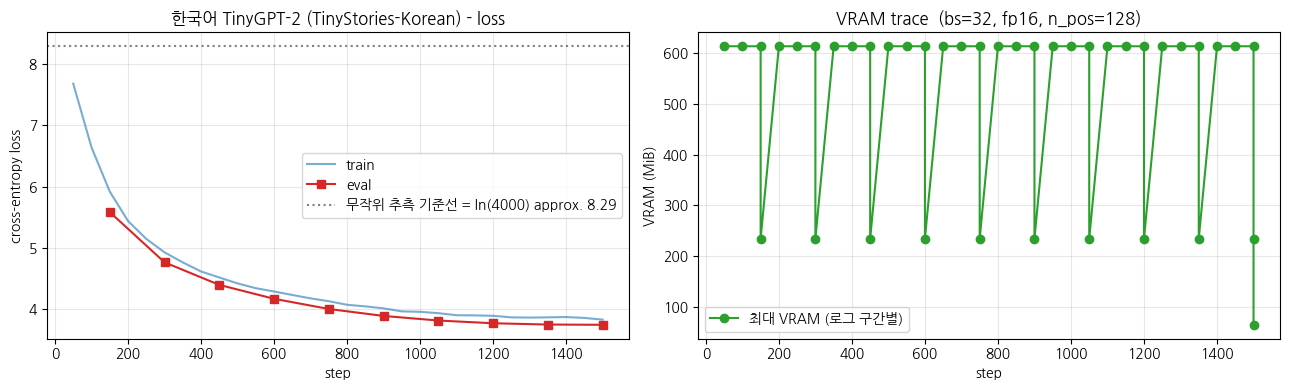

In [11]:
# loss curve + VRAM trace
log = trainer.state.log_history
train_pts = [(r["step"], r["loss"]) for r in log if "loss" in r and "eval_loss" not in r]
eval_pts  = [(r["step"], r["eval_loss"]) for r in log if "eval_loss" in r]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# loss
ax1.plot([s for s, _ in train_pts], [l for _, l in train_pts], "-",
         color="tab:blue", alpha=0.6, label="train")
if eval_pts:
    ax1.plot([s for s, _ in eval_pts], [l for _, l in eval_pts], "s-",
             color="tab:red", label="eval")
ax1.axhline(math.log(tokenizer.vocab_size), ls=":", color="gray",
            label=f"무작위 추측 기준선 = ln({tokenizer.vocab_size}) approx. {math.log(tokenizer.vocab_size):.2f}")
ax1.set_xlabel("step"); ax1.set_ylabel("cross-entropy loss")
ax1.set_title("한국어 TinyGPT-2 (TinyStories-Korean) - loss")
ax1.grid(True, alpha=0.3); ax1.legend()

# VRAM (CUDA 만)
if vram_cb.steps:
    ax2.plot(vram_cb.steps, vram_cb.peak_MiB, "o-", color="tab:green",
             label="최대 VRAM (로그 구간별)")
    ax2.set_title(f"VRAM trace  (bs=32, fp16, n_pos={BLOCK_SIZE})")
else:
    ax2.text(0.5, 0.5, "VRAM 추적은 CUDA 에서만 가능",
             ha="center", va="center", transform=ax2.transAxes)
    ax2.set_title("VRAM 추적 - CUDA 전용")
ax2.set_xlabel("step"); ax2.set_ylabel("VRAM (MiB)")
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout(); plt.show()

**관전 포인트** - 학습 첫 step loss 가 약 8.3 (random baseline `ln(4000)`) 부근에서 시작해 *수백 step 안에 약 5* 로 빠르게 떨어지고, 1500 step 끝에 누적 평균 `train_loss` 가 *약 4.5* 까지 내려가면 정상. 한국어는 번역체 데이터라 영어 챕터 (Ch 24, 약 3.7) 보다 도달 loss 가 다소 높지만 (학습률도 `3e-4 → 5e-4` 로 달라 언어 차이만의 효과는 아님), *수백 step 안에 random baseline 에서 빠르게 떨어지는 수렴 곡선* 자체는 동일합니다 — *언어가 달라도 작은 GPT + 30K stories 의 학습 동역학은 비슷하다*.

## 7. 학습 *후* generation + before/after 비교

같은 `PROMPTS / GEN_KWARGS` 로 학습 후 모델에서 다시 생성하고, §5 의 학습 전 결과와 나란히 비교합니다. **이 챕터의 합격 기준**: 학습 후 텍스트가 *전* 보다 명확히 *한국어 문장 (동화 풍)* 에 가까워졌는가 — Ch 24 (영어) 의 *사전·사후 비교* 의 한국어판.

In [12]:
torch.manual_seed(SEED)
model.eval()
after_outputs = []
print("=" * 70)
print("TRAINED model - generation after Trainer.train()")
print("=" * 70)
for p in PROMPTS:
    text = generate_text(model, p, **GEN_KWARGS)
    after_outputs.append(text)
    print(f"\nprompt: {p}")
    print(text)

TRAINED model - generation after Trainer.train()



prompt: 옛날 옛날에
옛날 옛날에 잭이라는 작은 소녀가 있었습니다. 그녀는 가장 좋아하는 꽃들로 있었어요. 어느 날, 루시는 그 집으로 갔고, 수라는 이름의 작은 소녀가 공원에 갔어요. 수라는 이름의 소녀가 친구인 소녀가 그 새를 봤어요. 수라는 그 새를 돕고 싶어졌습니다! 수는 그 새가 새를 돕고 싶어 했습니다. "안녕, 수는 그 새야



prompt: 작은 소녀가
작은 소녀가 엄마와 공원에 갔어요. 그녀는 크고 작은 집에서 살고 있었지요. 그 소녀는 그 그 집에서 살고 있었죠. 그녀는 친구들과 정원에서 노는 것을 좋아했어요. 어느 날, 그녀는 예쁜 꽃들을 발견했어요. 그 안에는 부드러운 꽃들이 있었어요. "안녕, 톰! 여기서 놀고 싶어?"라고 물었죠. 릴리는 말했죠. 그 여자아



prompt: 큰 개가
큰 개가 자신의 친구를 지시키며 그 여자아주를 쓰다. 그는 자신이 사랑했어. 엄마가 말했죠, "봐, 아이들. 네가 네 거야?" 팀은 말했습니다. "응, 엄마. 이제 넌 좋은 친구가 되어서 좋은 친구가 되고 있어. 그리고 네가 사랑해야 해." 그들은 종일 함께 놀았습니다



prompt: 어느 날,
어느 날, 팀이라는 소년이 땅에 앉아 있는 것을 봤어요. 그는 친구들과 함께 놀고 싶어 했지요. 그래서 그들은 큰 나무 아래에 앉아 있는 큰 나무를 발견했어요. 팀은 매우 슬퍼하며 그 벌레를 봤어요. 그 남자는 새를 봤어요. 팀은 새를 보고 정말 놀랐죠. 새는 새에게 말했어요. "고마워, 수 있을까?" 팀은 미소를 지으며 말했답니다.


In [13]:
# before / after 나란히 - 사전학습이 본체에 새긴 next-token 분포의 직접적 증거
print("=" * 78)
print("BEFORE (random init) vs AFTER (trained on TinyStories-Korean 30K)")
print("=" * 78)
for p, before, after in zip(PROMPTS, before_outputs, after_outputs):
    print(f"\nPROMPT  : {p}")
    print("-" * 78)
    print(f"BEFORE  : {before[len(p):].strip()[:280]}")
    print(f"AFTER   : {after[len(p):].strip()[:280]}")

BEFORE (random init) vs AFTER (trained on TinyStories-Korean 30K)

PROMPT  : 옛날 옛날에
------------------------------------------------------------------------------
BEFORE  : 살 살 깜짝 좋아 개구리가보�려주정말돌돌�� 진� � 회옛날에 갔 갔�도와 무� 가질 말 �일을 걸어서� 옛날 바라보며했답니다 시작했어요구를견 가장 잠 가져 사귀나게선 깨끗� T��구를일 상자에치 몸을� 신발 무릎 산책�요�채더�� 바나연 소� 그러자
AFTER   : 잭이라는 작은 소녀가 있었습니다. 그녀는 가장 좋아하는 꽃들로 있었어요. 어느 날, 루시는 그 집으로 갔고, 수라는 이름의 작은 소녀가 공원에 갔어요. 수라는 이름의 소녀가 친구인 소녀가 그 새를 봤어요. 수라는 그 새를 돕고 싶어졌습니다! 수는 그 새가 새를 돕고 싶어 했습니다. "안녕, 수는 그 새야

PROMPT  : 작은 소녀가
------------------------------------------------------------------------------
BEFORE  : 소녀가 �덩 싫어 쳐다 개미는 남하게 친한 자기 꾸 꾸 불� 도와주n��우인지머 자동차님은 정원을 노인 맜�니 수 잃 낮잠을니� 매우 놀았어요 놀았어요 너희 너희 대해혜에는 빨리 친한 몰랐습니다 몰랐습니다 나뭇가지를게요 하자� 가는장에서건� 장난감은 쿠키 �� 지�을 왜냐하면 그 바다��
AFTER   : 엄마와 공원에 갔어요. 그녀는 크고 작은 집에서 살고 있었지요. 그 소녀는 그 그 집에서 살고 있었죠. 그녀는 친구들과 정원에서 노는 것을 좋아했어요. 어느 날, 그녀는 예쁜 꽃들을 발견했어요. 그 안에는 부드러운 꽃들이 있었어요. "안녕, 톰! 여기서 놀고 싶어?"라고 물었죠. 릴리는 말했죠. 그 여자아

PROMPT  : 큰 개가
--------------------------------------

**해석 가이드 - 사전학습이 만든 차이**

- **BEFORE (random init)**: *한국어와 거리가 먼 음절·byte 조각 반복*. logits 가 random 초기값이라 sampling 이 통계적 빈도 토큰 사이에서만 흔들림.
- **AFTER (한국어 TinyStories 30K × 1500 steps)**: *말이 되는 한국어 문장* - 짧지만 *주어 + 서술어* 구조, *동화 풍 어휘* (소녀, 친구, 엄마, 행복, 숲, 토끼, ...). 완벽하진 않아도 *학습이 본체에 next-token 분포를 새긴 증거* 가 한 줄에서 명확.

> Ch 24 (영어) 의 *사전·사후 generation 비교* 에서 random init 모델이 의미 없는 토큰을 뽑다가 학습 후 *동화 풍 영어 문장* 을 만들어 낸 그 변화의 한국어판입니다. *번역체 데이터* 라 영어판보다 다소 어색할 수 있지만, *학습 전·후의 질적 도약* 자체는 동일하게 드러납니다.

## 🛠️ 변형 - sampling hyperparam / 더 큰 모델 / 더 많은 stories

같은 한국어 prompt 에 `temperature / top_k / top_p` 만 바꿔 generation 스타일 변화 관찰. *학습된 본체는 그대로* - 변하는 건 *sampling 분포* 뿐.

In [14]:
prompt = "옛날 옛날에 작은 토끼가"
configs = [
    {"label": "T=0.3, top_k=20  (conservative)", "temperature": 0.3, "top_k": 20,  "top_p": None},
    {"label": "T=0.8, top_k=50  (balanced)",    "temperature": 0.8, "top_k": 50,  "top_p": None},
    {"label": "T=1.0, top_p=0.9 (nucleus)",     "temperature": 1.0, "top_k": 0,   "top_p": 0.9},
    {"label": "T=1.2, top_k=100 (diverse)",     "temperature": 1.2, "top_k": 100, "top_p": None},
]
for c in configs:
    torch.manual_seed(SEED)
    print("=" * 70)
    print(f"[{c['label']}]")
    print(generate_text(model, prompt, max_new_tokens=60, do_sample=True,
                        temperature=c["temperature"], top_k=c["top_k"], top_p=c["top_p"]))
    print()

[T=0.3, top_k=20  (conservative)]


옛날 옛날에 작은 토끼가 있었어요. 그 새는 매우 좋아했지요. 어느 날, 새는 큰 나무를 봤어요. 그 새는 그 새는 매우 슬퍼했죠. 새는 매우 기뻐하며 "안녕, 새야! 나는 너를 사랑해."라고 말했죠. 새는 "안녕, 나는 너를 사랑해!"라고 말했죠. 새는 "고마워, 새야. 나는 너를 사랑해. 당신

[T=0.8, top_k=50  (balanced)]


옛날 옛날에 작은 토끼가 있었어요. 그 친구들은 매우 좋아했지요. 어느 날, 새는 큰 소리를 들었어요. 새는 큰 그 새는 나무 밑에서 놀고 있었어요. 새는 날지로 가고 싶었습니다. 새는 "저건 뭐지?"라고 물었어요. 새는 무서웠지만, 새는 슬퍼했죠. 새는 "괜찮아, 내 친구가 될 거라고 생각하지 마

[T=1.0, top_p=0.9 (nucleus)]


옛날 옛날에 작은 토끼가 있었어요. 그 친구들은 뛰는 것을 매우 좋아했죠. 그들은 젠프를 얻으라고 생각했어요. 어느 날, 새는 정원에 떨어지고 있는 큰 난장판을 만들었어요. 둘은 질문하고 싶었어요. 토끼는 밖으로 나가며 새 총겼지만, 새로운 게임을 하겠다고 했어요. 동물들은 모두 음악을 지냈어요. 깊은 숨을

[T=1.2, top_k=100 (diverse)]


옛날 옛날에 작은 토끼가 있었어요. 그 친구들은 길을 찾을 수 있었어요. 그들은 큰 빨간 공으로 노는 걸 보려고 그 차를 보았어요. 보물들은 매우 기뻐했답니다. "아니요, 이 개는 정말 멋진 일을 하며요!"라고 고양이는 "우리, 네 거란다."라고 팀이 말했죠. "나랑 같이 놀 수는 게임을 떠



**관전 포인트**

- `temperature` ↑ → logits 분포 *평탄화* → 다양성 ↑, 일관성 ↓
- `top_k=20` → 매 step 후보를 *상위 20 개* 로만 한정 → 안전하지만 반복적
- `top_p=0.9` (nucleus) → 누적 확률 90% 이내 후보 → *모델이 확신 있을 땐 좁게, 애매할 땐 넓게* 자동 조정
- `T=1.2, top_k=100` → 가장 다양하지만 *말이 안 되는 토큰* 도 종종 섞임

**더 큰 개선을 원하면** (T4 30분 룰 안):

| 변형 축 | 이번 챕터 (기본) | 변형 예 | 예상 효과 |
|---|---|---|---|
| `N_TRAIN` (story 수) | 30,000 | 60,000 | 한국어 문장 자연스러움 ↑, 학습 시간 비례 증가 |
| `n_embd` / `n_layer` | 256 / 4 | 384 / 6 | 표현력 ↑ (약 8M params), T4 메모리 안에서 가능 |
| `max_steps` | 1500 | 2500 | loss 추가 하락, 30분 룰 주의 |
| 다른 한국어 코퍼스 | TinyStories-Korean | 한국어 위키 + 동화 혼합 | 도메인 폭 ↑, 단 어휘 난도 ↑ |

## 8. (선택) Reference 비교 - KoGPT2 의 같은 prompt generation

*학습이 충분히 잘 된* 기준점으로 `skt/kogpt2-base-v2` (125M, 대규모 한국어 사전학습) 에 같은 한국어 prompt 를 넣어 *우리 작은 GPT (약 4.2M, 한국어 TinyStories 30K)* 와 격차를 봅니다. **Ch 27 이 KoGPT2 본격 챕터** 이므로 여기서는 *간단히 한 번만* — T4 시간을 아끼려면 이 셀은 건너뛰어도 됩니다.

In [15]:
# 선택 셀 - KoGPT2 reference. 시간이 부족하면 RUN_KOGPT2_REF = False 로 두고 건너뜁니다.
RUN_KOGPT2_REF = True

if RUN_KOGPT2_REF:
    from transformers import PreTrainedTokenizerFast, AutoModelForCausalLM

    print("loading reference KoGPT2 (skt/kogpt2-base-v2, 125M)...")
    # 주의: KoGPT2 는 AutoTokenizer 가 영어 GPT2 토크나이저로 잘못 fallback 합니다
    # (transformers 5.x — 한국어 prompt 가 깨진 byte 로 인코딩돼 generation 이 �·▁ 나열로 나옴).
    # SKT 공식 방식대로 PreTrainedTokenizerFast 로 special token 을 직접 지정해 로드합니다 (Ch 27 과 동일).
    ref_tok = PreTrainedTokenizerFast.from_pretrained(
        "skt/kogpt2-base-v2",
        bos_token="</s>", eos_token="</s>", unk_token="<unk>",
        pad_token="<pad>", mask_token="<mask>",
    )
    ref_model = AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2").to(device).eval()
    print(f"  #params : {ref_model.num_parameters()/1e6:.1f} M")

    torch.manual_seed(SEED)
    print("\n" + "=" * 70)
    print("REFERENCE KoGPT2 (125M) - generation on same Korean prompts")
    print("=" * 70)
    for p in PROMPTS:
        text = generate_text(ref_model, p, gen_tokenizer=ref_tok, **GEN_KWARGS)
        print(f"\nprompt: {p}")
        print(text)

    # 메모리 정리
    del ref_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
else:
    print("Skipped KoGPT2 reference (RUN_KOGPT2_REF=False). Covered in depth in Ch 27.")

loading reference KoGPT2 (skt/kogpt2-base-v2, 125M)...


tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  513MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

  #params : 125.2 M

REFERENCE KoGPT2 (125M) - generation on same Korean prompts



prompt: 옛날 옛날에
옛날 옛날에 네들이 말했잖아. 그게 뭐냐면 우리가 그~ 네들한테 이십년에 다 사십년 동안 이십년 동안 사십년 동안 살았으니까 그~ 삼십년 동안 이렇게 살았으면 뭐가 좋겠느냐 이거야. 그런



prompt: 작은 소녀가
작은 소녀가 된 후 소녀에게 한 번도 성적으로 관심을 갖지 않았다.
그녀가 소녀가 된 후에는 그녀의 사랑을 알게 되었다.
그녀가 고등학교에 진학했을 때, 그들은 소녀를 볼 때마다 미소를 짓고 그녀를 바라봤다.
마치 그처럼 그녀는 소녀처럼 소녀를 보았다.
그때마다 소녀는 소녀를 위해 무엇인가를 해 주고 있었다.




prompt: 큰 개가
큰 개가 되어버린 것입니다.
그래서 모든 것을 초월하여 하나로 통합하고, 하나로 통합하는 것이 바로 그 무엇이라는 것을 강조하고 있는 것입니다.
하나의 힘을 하나로 통합하는 것이 바로 통합인 것입니다.
우리는 하나님의 말씀을 통해서 하나님의 능력을 충분히 깨닫습니다.
그 능력은 하나님의 말씀을 통해서 우리에게 전달되기도 하고, 또 하나



prompt: 어느 날,
어느 날, 김정은은 노동당 대표자회에서 '국지전'을 펼쳤다고 김정은은 밝혔다.
하지만 김정은은 '국지전' 대신 '국지전'이라는 표현을 쓰면서 '국지전'에 대한 언급을 피했다.
북한은 김정은이 국지전 연설을 하며 '국지전


**해석 가이드 - 규모가 만든 격차**

- **OURS (약 4.2M, 한국어 TinyStories 30K)**: *동화 풍 단순 한국어* - 어휘는 동화 도메인에 강하지만 *복잡한 문장 구조 / 추상적 어휘* 는 약함.
- **REF (KoGPT2 125M, 대규모 한국어 코퍼스)**: *다양한 도메인 어휘 + 자연스러운 문장 흐름*. 학습 데이터의 규모·다양성이 generation 다양성으로 직결.

> Ch 27 이 이 격차를 *데이터 축을 통제하고* 다룹니다 - KoGPT2 (125M) 의 사전학습 *위에* 같은 한국어 TinyStories 로 **continual pretraining**. *대규모 한국어 사전학습 모델을 작은 도메인 데이터로 적응* 시킬 때의 generation 품질이, 우리 from-scratch 작은 GPT 와 어떻게 다른지 직접 비교 (Ch 24→25 의 한국어 짝).

## 📦 이번 챕터에 등장한 라이브러리·함수 (Ch 24 와의 차이만)

| 이름 | 한 줄 설명 | Ch 24 와 차이 |
|---|---|---|
| `load_dataset("g0ster/TinyStories-Korean", streaming=True)` | 한국어 TinyStories 줄 단위 스트리밍 로드 | 영어 → 한국어, story 복원 로직 추가 |
| `tokenizers.BPE + ByteLevel` (한국어 코퍼스) | byte-level BPE (BBPE) 직접 학습 | 학습 코퍼스 영어 → 한국어, vocab 2,048 → 약 4,000 |
| `AutoTokenizer.from_pretrained("gpt2")` (비교용) | 영어 BPE 로 한국어 토큰화 비교 | 신규 (cross-language 실측) |
| `transformers.GPT2Config / GPT2LMHeadModel(config)` (동일) | 작은 GPT random init | (Ch 24 동일, vocab 만 다름) |
| `DataCollatorForLanguageModeling(mlm=False)` (동일) | `labels = input_ids.clone()` 자동 | (Ch 24 동일) |
| `group_texts` 패턴 (동일) | 가변 길이 → 고정 length 블록 스트림 | (Ch 24 동일) |
| `model.generate(do_sample=True, ...)` (동일) | sampling generation | (Ch 24 동일) |
| `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` (선택) | KoGPT2 reference — 토크나이저는 `PreTrainedTokenizerFast` 로 special token 직접 지정 (`AutoTokenizer` 는 영어 GPT2 로 fallback) | gpt2 → KoGPT2 |

## 🎯 체크포인트 질문

1. 영어 gpt2 BPE 로 한국어를 토큰화하면 토큰 수가 폭증합니다 (셀 비교 표). *byte-level* 이라 UNK 는 없는데, 왜 그래도 *직접 학습한 BBPE* 가 한국어 학습에 유리할까요? (의미 단위 보존 vs byte 조각 분해 관점)
2. random baseline 이 Ch 24 (vocab 2,048) 의 `ln(2048) ≈ 7.62` 에서 Ch 26 (vocab 약 4,000) 의 `ln(4000) ≈ 8.29` 로 바뀝니다. 이 차이가 *학습 동역학* 에 의미 있는 영향을 주나요? *학습 종료 loss 의 절대값* 을 영어 챕터와 비교할 때는요?
3. 본 챕터의 collator 가 만드는 `labels` 는 *거의 모든 자리* 가 학습 신호입니다. Ch 28 (한국어 SFT) 에서는 `labels[:prompt_len] = -100` 한 줄로 *prompt 부분만 제외* 합니다. *왜 이 한 줄이 모델이 한국어 instruction 을 따라가게 만드는지* 설명해 보세요.
4. 같은 본체 구조·loss·trainer 로 영어 (Ch 24) 와 한국어 (Ch 26) 를 학습했습니다. 학습 곡선·generation 품질이 두 언어에서 비슷하게 나온다면, *언어 자체의 난도 차이* 와 *데이터 규모·번역체 차이* 중 무엇이 generation 품질에 더 큰 영향을 줄까요?

## ❓ FAQ

### Q1. (이론) 한국어 BBPE 는 영어 BPE 와 무엇이 다른가요? byte-level 이 한글을 어떻게 처리하나요?

**알고리즘은 *완전히 같습니다* — 다른 건 *학습 코퍼스* 뿐**. 둘 다 byte-level BPE (BBPE):

- *가장 작은 단위가 byte (256개)* 라 한글·이모지·한자 *어떤 유니코드도 UNK 없이* 표현.
- 한글 `가` 는 UTF-8 로 3 byte (`0xEA 0xB0 0x80`). BBPE 는 학습 중 *자주 함께 등장하는 byte 쌍* 을 반복 병합해 *글자·어절 단위* 토큰을 만듦.

차이는 *어떤 코퍼스로 학습했는가*. 영어 코퍼스로 학습한 gpt2 BPE 는 *영어 byte 패턴* 의 병합 규칙을 갖고 있어, 한국어를 넣으면 한글 byte 가 거의 *원자 단위 그대로* 나와 토큰 수가 폭증합니다.

```python
# 같은 문장, 두 토크나이저
sent = "옛날 옛날에 작은 토끼가 살았어요."
len(gpt2_tok(sent, add_special_tokens=False)["input_ids"])    # 많음 (byte 조각)
len(tokenizer(sent, add_special_tokens=False)["input_ids"])   # 적음 (의미 단위)
```

한국어 코퍼스 위에 직접 학습하면 *한국어 어절의 byte 패턴* 이 병합 규칙에 반영되어 *훨씬 적은, 의미 있는 토큰* 으로 압축됩니다.

### Q2. (이론) 왜 한국어도 *scratch* 부터 학습하나요? Ch 24 (영어 scratch) 를 이미 했는데.

**같은 시연 가치 + 한국어 특유의 필요성** 때문입니다.

1. *시연 가치* — 사전학습이 본체에 *next-token 분포* 를 새기는 과정을 *한국어로* 직접 봅니다 (Ch 20→22 가 BERT 에서 한 것의 GPT 판).
2. *한국어 특유의 필요성* — 영어는 gpt2 BPE 를 그대로 가져다 continual pretraining (Ch 25) 이 가능했지만, *영어 BPE 는 한국어를 byte 조각으로 쪼개* 사실상 못 씁니다. 그래서 한국어는 *토크나이저부터 새로* — 자연스럽게 *scratch* 가 됩니다.

```python
# 한국어는 토크나이저 + 본체 모두 처음부터
bbpe = Tokenizer(BPE(unk_token=None))      # 토크나이저 직접 학습
model = GPT2LMHeadModel(config)            # 본체 random init
```

*토크나이저는 본체와 운명공동체* — 토크나이저가 한국어를 못 다루면 본체 weight 도 유효한 신호를 받지 못합니다.

### Q3. (실무) 다음 챕터 (Ch 27 KoGPT2 continual pretraining) 와의 관계는?

Ch 27 = *대규모 한국어 사전학습 모델 KoGPT2 (`skt/kogpt2-base-v2`, 125M) 를 같은 한국어 TinyStories 로* **continual pretraining**. 본 챕터의 *작은 from-scratch 모델* 과 *완전 반대 출발점* — Ch 24→25 (영어) 의 한국어 짝:

| 축 | Ch 26 (본 챕터) | Ch 27 (다음) |
|---|---|---|
| 모델 크기 | 약 4.2M params | **약 125M (약 30배)** |
| 사전학습 | from scratch (random init) | **대규모 한국어 코퍼스 사전학습** |
| 토크나이저 | 직접 학습 BBPE vocab 약 4,000 | **KoGPT2 BBPE (그대로)** |
| 한국어 TinyStories 학습 | 사전학습 그 자체 (1500 steps) | **continual pretraining** (수백 steps) |
| Generation 품질 | 동화 풍 단순 한국어 | **자연스러운 동화 + 일반 도메인 폭** |

**핵심 메시지**: *대규모 한국어 사전학습 본체* + *작은 도메인 continual pretraining* 이 *작은 from-scratch 모델* 보다 *빠르게, 좋게* 도달합니다. *왜 실무는 from-scratch 가 아니라 사전학습 모델을 가져와 계속 학습하는가* 의 한국어 답.

### Q4. (이론) 한국어 CausalLM 사전학습도 `labels = -100` 트릭을 쓰나요?

**거의 안 씁니다 — pad 자리만**. Ch 24 (영어) 와 동일하게, 본 챕터 collator 출력은 *거의 모든 자리* 가 학습 신호 (`labels = input_ids.clone()`). `group_texts` 로 chunk 길이가 모두 같으면 pad 도 없어 `-100` 이 0개일 수 있습니다.

같은 트릭이 **Ch 28 (한국어 SFT)** 에서 *결정적 한 줄* 로 부활합니다:

```python
# Ch 28 의 SFT 데이터 - "instruction + response" 형식
prompt = "### 질문: 한국의 수도는?\n### 답변: "
response = "서울입니다."

input_ids = tokenizer(prompt + response)["input_ids"]
labels = input_ids.copy()
prompt_len = len(tokenizer(prompt)["input_ids"])
labels[:prompt_len] = [-100] * prompt_len   # <- 이 한 줄이 SFT 의 핵심
```

이 한 줄로 모델은 *prompt 를 외우지 않고 response 만 학습* → *주어진 instruction 에 response 를 생성* 하게 됩니다. 본 챕터의 collator 출력 (거의 모든 자리 = 학습 신호) 을 손에 익혀 두면 Ch 28 의 그 한 줄이 단번에 이해됩니다.

### Q5. (실무) 한국어 generation 품질이 영어 (Ch 24) 보다 낮아 보이면 무엇을 의심하나요?

세 가지 원인을 순서대로 점검합니다.

1. **데이터 양·품질** — `g0ster/TinyStories-Korean` 은 *기계 번역본* 이라 원문 영어 TinyStories 보다 문장이 다소 어색하거나 일관성이 떨어질 수 있습니다. story 복원 (`<|endoftext|>` 기준) 이 제대로 됐는지, story 수가 충분한지 확인.

```python
# story 복원 검증 - 한 story 가 통째로 나오는지
print(raw_train[0]["text"][:300])   # 문장이 자연스럽게 이어지면 복원 정상
print(f"n_stories: {len(raw_train):,}")
```

2. **토크나이저** — vocab 약 4,000 이 너무 작으면 한 어절이 여러 byte 조각으로 쪼개져 학습이 어렵습니다. `VOCAB_SIZE` 를 6,000-8,000 으로 키워 비교.

3. **학습량** — `max_steps` 또는 `N_TRAIN` 을 키우면 한국어 문장 자연스러움이 올라갑니다 (T4 30분 룰 주의).

> *번역체 데이터* 라 영어판보다 다소 어색한 건 *정상* — 본 챕터의 목표는 *완벽한 한국어 생성* 이 아니라 *학습 전·후의 질적 도약* 을 한국어로 확인하는 것. 자연스러운 한국어 generation 은 Ch 27 (KoGPT2 continual pretraining) 의 영역.

### Q6. (이론) Ch 24 (영어) 와 Ch 26 (한국어) 의 학습 곡선을 비교하려면?

같은 hyperparam·같은 BLOCK_SIZE·같은 step 수로 학습된 두 모델의 *상대* 비교가 의미 있습니다.

```python
metrics = {
    "language":          ["EN (Ch 24)",  "KO (Ch 26)"],
    "vocab_size":        [2048,          4000],
    "random_baseline":   [7.62,          8.29],
    "final_train_loss":  ["measure",     "measure"],
}
```

vocab 크기가 다르므로 *random baseline (`ln V`) 이 다릅니다*. 절대 loss 를 직접 비교하기보다 *random baseline 대비 얼마나 떨어졌는가* (상대 하락폭) 로 비교해야 공정합니다. 또 *번역체 한국어* 는 원문 영어보다 *반복·패턴* 이 적을 수 있어 같은 step 에서 loss 가 약간 높게 나올 수 있습니다 — *언어 난도* 보다 *데이터 특성* 차이가 더 큽니다.

### Q7. (실무) 학습 첫 step loss 가 `ln(4000) ≈ 8.29` 가 아니라 *5.0* 이라면? *15.0* 이라면?

- **5.0 (너무 낮음)**: vocab 크기 가정이 틀렸거나 (실제 vocab 이 더 작음), 토크나이저가 prompt 를 *비정상적으로 적은 토큰* 으로 만들거나, 데이터가 *극도로 반복적* 이어서 첫 배치가 쉬운 경우. `tokenizer.vocab_size` 와 `math.log(tokenizer.vocab_size)` 를 출력해 baseline 을 확인.

```python
print(f"vocab: {tokenizer.vocab_size}, ln V = {math.log(tokenizer.vocab_size):.2f}")
```

- **15.0 (너무 높음)**: `ln(4000) ≈ 8.29` 보다 훨씬 높다면 *vocab 불일치* (모델 config 의 `vocab_size` 와 토크나이저가 다름) 또는 *입력 id 가 vocab 범위를 벗어남* 을 의심. `config.vocab_size == tokenizer.vocab_size` 인지 점검하세요. random init 의 자연스러운 시작은 *baseline 근처* 입니다.

## 다음 챕터 예고

**Chapter 27. KoGPT2 Continual Pretraining 으로 한국어 TinyStories 에 적응 — *Ch 25 의 한국어판***

- `AutoModelForCausalLM.from_pretrained("skt/kogpt2-base-v2")` - 대규모 한국어 코퍼스로 사전학습된 125M params KoGPT2 로드
- **같은 한국어 TinyStories** 데이터 (본 챕터와 동일) 로 **continual pretraining** (계속 사전학습 — *같은 CausalLM task, 새 데이터, head 그대로*. *task adaptation 의미의 fine-tune 이 아니라 단계 2*)
- **핵심 비교**: 본 챕터 (약 4.2M, from scratch) vs Ch 27 (125M, continual pretraining) 의 한국어 generation 품질·학습 곡선 격차
- *trainer 자체는 Ch 26 과 동일* (`transformers.Trainer` + `DataCollatorForLanguageModeling(mlm=False)`) - *변하는 건 모델 로드 한 줄 + lr (scratch 5e-4 → continual pretraining 2e-5)*
- Ch 24→Ch 25 (영어) 의 한국어 짝 - *왜 실무가 from-scratch 가 아니라 대규모 사전학습 모델 위에 계속 학습하는가* 의 한국어 정량 답변

> **변하는 축**: *모델 크기 + 사전학습 여부* (4.2M / scratch → 125M / pretrained). 데이터·토크나이저 규약·loss·trainer 는 같음. Phase 4 의 *학습 단계 2 (continual pretraining)* 가 한국어에서 자리 잡는 챕터. *진짜 행동 정렬 (SFT)* 은 Ch 28 에서 본격 등장합니다.